<div style="color:#3c4d5a; border-top: 7px solid #42A5F5; border-bottom: 7px solid #42A5F5; padding: 5px; text-align: center; text-transform: uppercase">
<h1>Reconocimiento de Especies de Hojas mediante Shape Signature (FFT)</h1>
<p style="text-transform: none; font-size: 14px; color: #666;">Flavia Dataset — Descriptores de Fourier con Coordenadas Complejas</p>
</div>

Realizado por: **Kevin Andres Morocho Remache** — Correo de contacto: kmorochor1@est.ups.edu.ec  
Grupo: **G1** (Mejía Morocho Bryam Andrés | Morocho Remache Kevin Andres)  
Clases asignadas: **0, 1, 2, 3, 4, 5, 6**

Este cuaderno implementa un sistema de reconocimiento de especies de hojas utilizando el **Flavia Dataset** 
y el descriptor **Shape Signature** basado en la Transformada Rápida de Fourier (FFT) con coordenadas complejas.

El trabajo se divide en las siguientes etapas:

1. [Carga y exploración del dataset](#carga_dataset)

    Lectura del Flavia Dataset, filtrado de las 7 clases asignadas (0–6) y exploración visual.

2. [Preprocesamiento de imágenes](#preprocesamiento)

    Conversión a escala de grises, suavizado, binarización y extracción de contornos.

3. [Extracción de descriptores (Shape Signature – FFT)](#extraccion_descriptores)

    Cálculo de la firma espectral mediante coordenadas complejas y normalización por el primer armónico.

4. [Aumento de datos con Albumentations](#aumento_datos)

    Generación de variantes mediante rotaciones para mejorar la robustez del clasificador.

5. [Clasificación y evaluación](#clasificacion)

    Clasificación por distancia Euclídea, matrices de confusión y análisis de errores.

6. [Conclusiones](#conclusiones)

7. [Referencias](#referencias)

El objetivo principal es validar el pipeline de reconocimiento antes de portarlo a una aplicación móvil nativa en C++.

<div id="carga_dataset" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Carga y exploración del dataset</h2>
</div>

<div style="color:#106ba3"><h3>Importaciones</h3></div>

In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

# Semilla para reproducibilidad
np.random.seed(42)

<div style="color:#106ba3"><h3>Carga del Flavia Dataset</h3></div>

El Flavia Dataset contiene 1907 imágenes de hojas distribuidas en 32 clases (0–31). 
El archivo `all.csv` contiene el mapeo entre cada imagen (`id`) y su clase (`y`). 
Según la **Tabla 2** de la guía, al Grupo G1 le corresponden las **clases 0, 1, 2, 3, 4, 5 y 6**.

In [2]:
# Ruta del dataset (ajustar según entorno local o Kaggle)
DATASET_PATH = "./Leaves"
CSV_PATH = os.path.join(DATASET_PATH, "all.csv")

# Clases asignadas al Grupo G1
CLASES_ASIGNADAS = [0, 1, 2, 3, 4, 5, 6]

# Leer el CSV
df = pd.read_csv(CSV_PATH)
print(f"Total de imágenes en el dataset: {len(df)}")
print(f"Clases disponibles: {sorted(df['y'].unique())}")
print(f"Columnas: {df.columns.tolist()}")
df.head(10)

Total de imágenes en el dataset: 1907
Clases disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Columnas: ['Unnamed: 0', 'id', 'y']


,Unnamed: 0,id,y
0,0,1300.jpg,5
1,1,3152.jpg,23
2,2,1439.jpg,9
3,3,1243.jpg,4
4,4,1186.jpg,3
5,5,1452.jpg,9
6,6,2063.jpg,11
7,7,1522.jpg,8
8,8,2007.jpg,10
9,9,2191.jpg,13


<div style="color:#106ba3"><h3>Filtrado de clases asignadas (G1: 0–6)</h3></div>

In [3]:
# Filtrar solo las clases asignadas
df_g1 = df[df["y"].isin(CLASES_ASIGNADAS)].copy()
df_g1 = df_g1.reset_index(drop=True)

print(f"Imágenes filtradas (clases 0-6): {len(df_g1)}")
print()
print("Distribución por clase:")
print(df_g1.groupby("y").size().to_frame("cantidad"))
print(f"\nTotal: {len(df_g1)} imágenes")

Imágenes filtradas (clases 0-6): 450

Distribución por clase:
   cantidad
y          
0        59
1        63
2        65
3        72
4        73
5        56
6        62

Total: 450 imágenes


<div style="color:#106ba3"><h3>Carga de imágenes en memoria</h3></div>

Se cargan todas las imágenes de las 7 clases asignadas, convirtiéndolas a escala de grises 
y asociando cada una con su etiqueta correspondiente.

In [4]:
images = []
labels = []
filenames = []
errores_carga = 0

for _, row in df_g1.iterrows():
    img_path = os.path.join(DATASET_PATH, row["id"])
    img = cv2.imread(img_path)
    
    if img is not None:
        images.append(img)
        labels.append(row["y"])
        filenames.append(row["id"])
    else:
        errores_carga += 1

labels = np.array(labels)

print(f"Imágenes cargadas exitosamente: {len(images)}")
if errores_carga > 0:
    print(f"Imágenes con error de carga: {errores_carga}")
print(f"Distribución: {dict(Counter(labels))}")

Imágenes cargadas exitosamente: 450
Distribución: {np.int64(5): 56, np.int64(4): 73, np.int64(3): 72, np.int64(1): 63, np.int64(6): 62, np.int64(0): 59, np.int64(2): 65}


<div style="color:#106ba3"><h3>Exploración visual del dataset</h3></div>

Se muestra una imagen representativa de cada clase para comprender visualmente las diferencias morfológicas entre las especies de hojas asignadas.

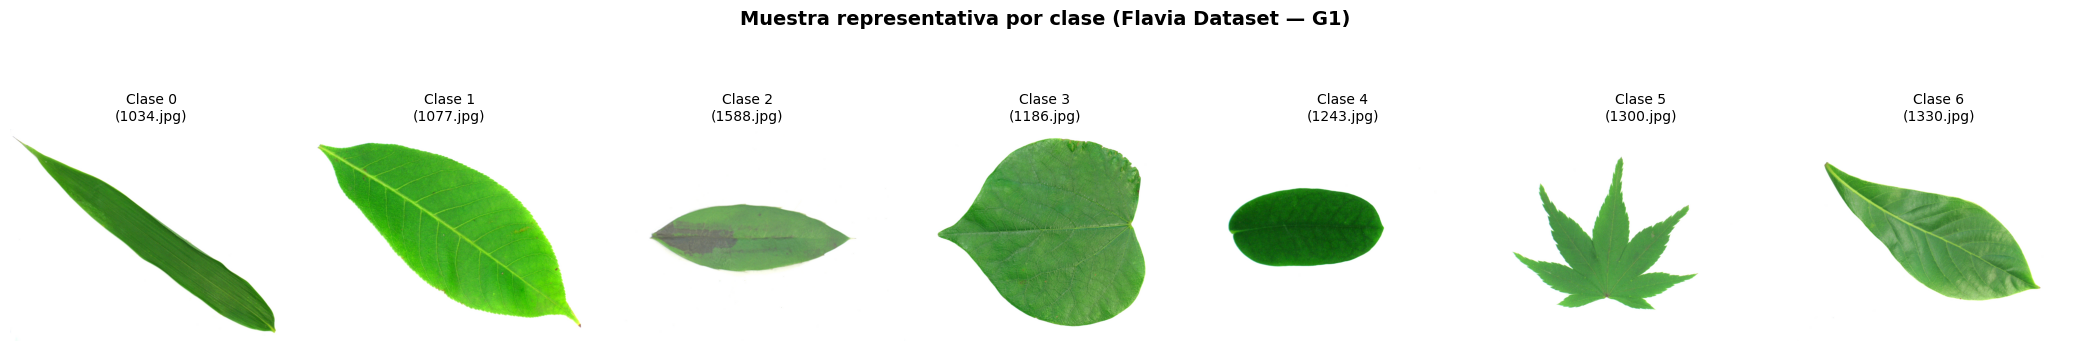

In [5]:
fig, axes = plt.subplots(1, 7, figsize=(21, 4))
fig.suptitle("Muestra representativa por clase (Flavia Dataset — G1)", fontsize=14, fontweight="bold", y=1.02)

for i, clase in enumerate(CLASES_ASIGNADAS):
    # Tomar la primera imagen de cada clase
    idx = np.where(labels == clase)[0][0]
    img_rgb = cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"Clase {clase}\n({filenames[idx]})", fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

<div style="color:#106ba3"><h3>Distribución de clases</h3></div>

Se verifica que la distribución de imágenes por clase es razonablemente equilibrada.

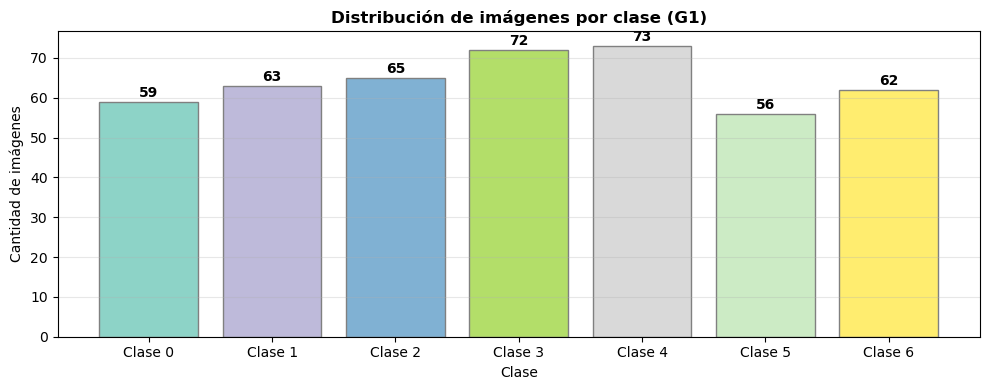

Total: 450 imágenes
Mínimo por clase: 56 | Máximo: 73 | Promedio: 64.3


In [6]:
conteos = [np.sum(labels == c) for c in CLASES_ASIGNADAS]
colores = plt.cm.Set3(np.linspace(0, 1, len(CLASES_ASIGNADAS)))

plt.figure(figsize=(10, 4))
bars = plt.bar([f"Clase {c}" for c in CLASES_ASIGNADAS], conteos, color=colores, edgecolor="gray")

# Agregar valor sobre cada barra
for bar, count in zip(bars, conteos):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha="center", va="bottom", fontweight="bold")

plt.title("Distribución de imágenes por clase (G1)", fontweight="bold")
plt.ylabel("Cantidad de imágenes")
plt.xlabel("Clase")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total: {sum(conteos)} imágenes")
print(f"Mínimo por clase: {min(conteos)} | Máximo: {max(conteos)} | Promedio: {np.mean(conteos):.1f}")

<div id="preprocesamiento" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Preprocesamiento de imágenes</h2>
</div>

El preprocesamiento tiene como objetivo aislar la silueta de la hoja (contorno) del fondo, 
siguiendo el flujo descrito en la Ilustración 4 de la guía:

1. Conversión a escala de grises
2. Suavizado Gaussiano para reducir ruido
3. Binarización mediante umbral adaptativo
4. Detección del contorno externo principal con `cv2.findContours`

<div style="color:#106ba3"><h3>Función de preprocesamiento</h3></div>

In [7]:
def preprocess_leaf(img, size=(256, 256)):
    """
    Preprocesa una imagen de hoja para extraer su contorno.
    """
    # Redimensionar
    img_resized = cv2.resize(img, size)
    
    # Escala de grises
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    
    # Suavizado Gaussiano
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Binarización con umbral adaptativo (como pide la guía)
    binary = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=25,
        C=8
    )
    
    # Operaciones morfológicas para cerrar huecos y limpiar ruido
    # USAMOS UN KERNEL MÁS GRANDE (15x15) PARA CERRAR LAS ROTURAS DEL BORDE
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=2)
    
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_open, iterations=1)
    
    # RELLENAR la silueta de la hoja:
    h, w = binary.shape
    filled = binary.copy()
    mask = np.zeros((h + 2, w + 2), np.uint8)
    
    # Inundar desde las 4 esquinas (el fondo)
    cv2.floodFill(filled, mask, (0, 0), 255)
    cv2.floodFill(filled, mask, (w - 1, 0), 255)
    cv2.floodFill(filled, mask, (0, h - 1), 255)
    cv2.floodFill(filled, mask, (w - 1, h - 1), 255)
    
    # Invertir: lo que NO es fondo = hoja rellena
    filled_inv = cv2.bitwise_not(filled)
    
    # Combinar con la imagen binaria original (unión)
    binary = cv2.bitwise_or(binary, filled_inv)
    
    # Encontrar contornos de la silueta rellena
    cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    if len(cnts) == 0:
        return binary, None
    
    # Tomar el contorno más grande (la hoja)
    contour = max(cnts, key=cv2.contourArea)
    
    return binary, contour

<div style="color:#106ba3"><h3>Validación visual del preprocesamiento</h3></div>

Se muestra el proceso completo (original → escala de grises → binarizada → contorno detectado) 
para verificar que la silueta de la hoja se extrae correctamente en cada clase.

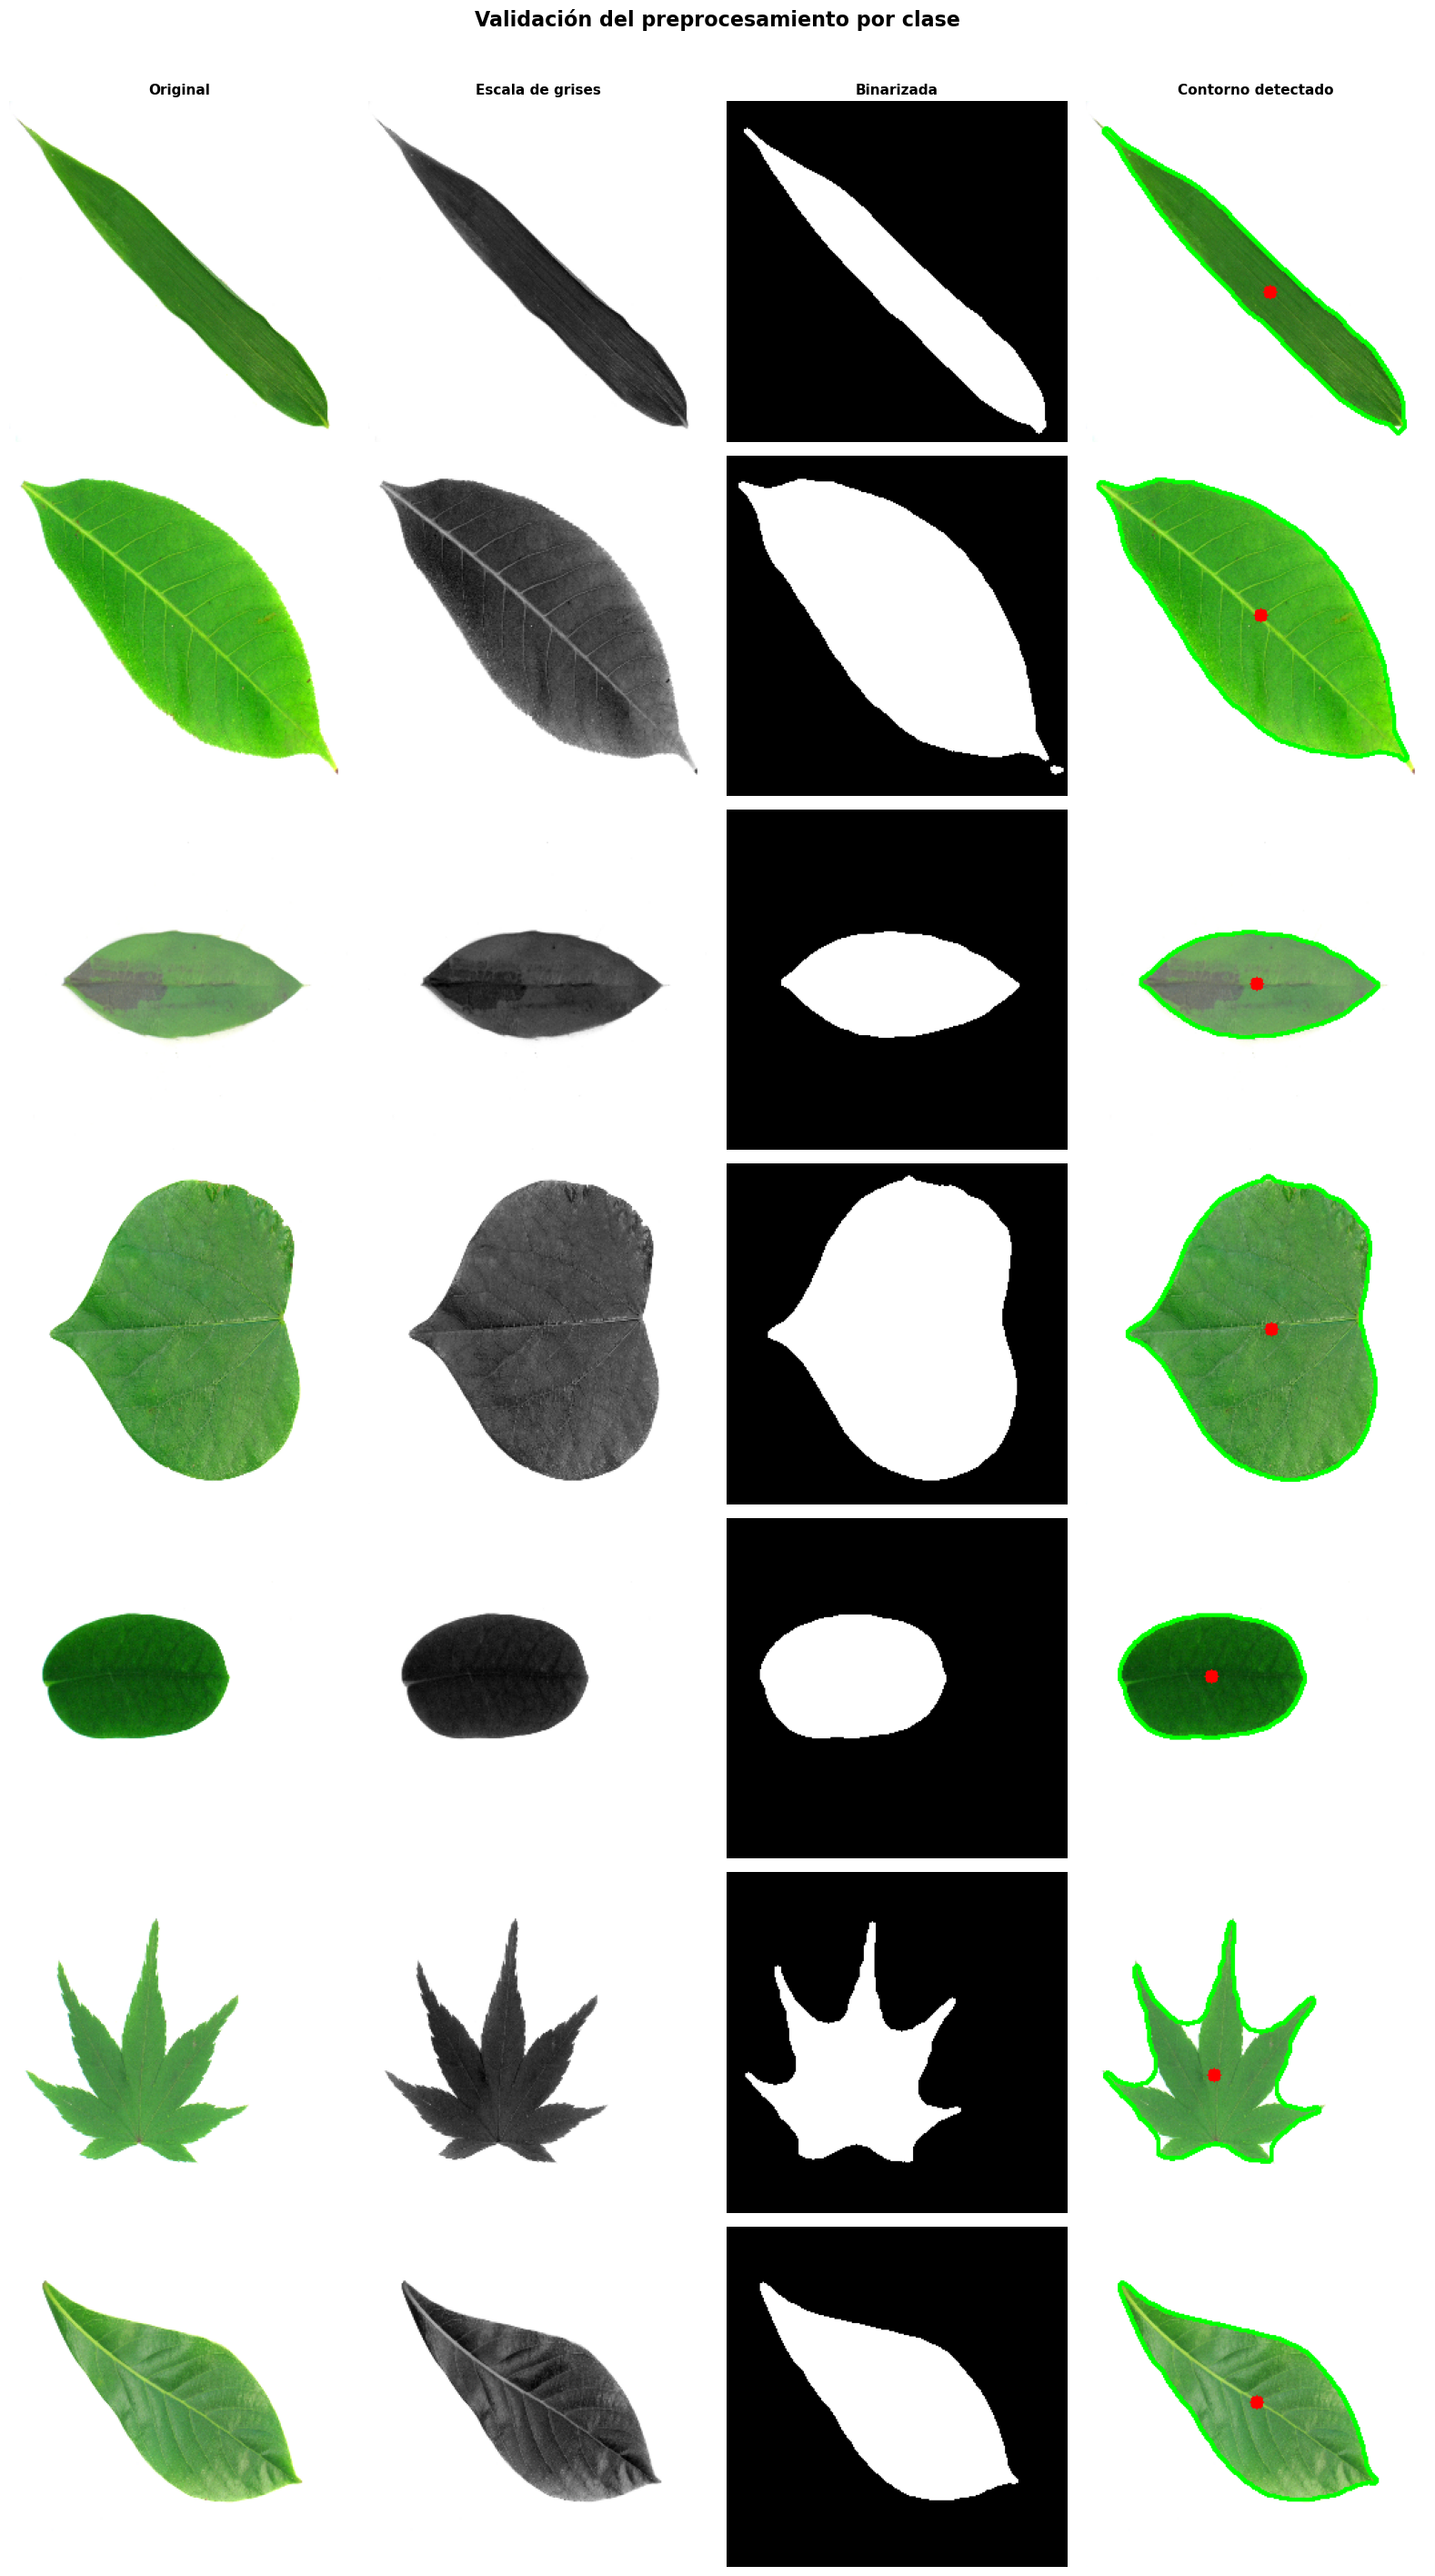

In [8]:
fig, axes = plt.subplots(7, 4, figsize=(16, 28))
fig.suptitle("Validación del preprocesamiento por clase", fontsize=16, fontweight="bold", y=1.01)

col_titles = ["Original", "Escala de grises", "Binarizada", "Contorno detectado"]

for i, clase in enumerate(CLASES_ASIGNADAS):
    idx = np.where(labels == clase)[0][0]
    img = images[idx]
    img_resized = cv2.resize(img, (256, 256))
    
    # Pasos intermedios
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    binary, contour = preprocess_leaf(img)
    
    # Dibujar contorno sobre la imagen original
    contour_img = img_resized.copy()
    if contour is not None:
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 2)
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.circle(contour_img, (cx, cy), 5, (0, 0, 255), -1)
    
    # Mostrar
    axes[i][0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    axes[i][0].set_ylabel(f"Clase {clase}", fontsize=12, fontweight="bold")
    
    axes[i][1].imshow(gray, cmap="gray")
    axes[i][2].imshow(binary, cmap="gray")
    axes[i][3].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    
    for j in range(4):
        axes[i][j].axis("off")
        if i == 0:
            axes[i][j].set_title(col_titles[j], fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="color:#106ba3"><h3>Preprocesar todo el dataset</h3></div>

Se aplica el preprocesamiento a todas las imágenes, almacenando las imágenes binarizadas 
y los contornos válidos. Se descartan las imágenes cuyo contorno no pueda extraerse.

In [9]:
X_binary = []      # imágenes binarizadas
X_contours = []    # contornos extraídos
y_labels = []      # etiquetas
X_filenames = []   # nombres de archivo
descartadas = 0

for img, label, fname in zip(images, labels, filenames):
    binary, contour = preprocess_leaf(img)
    
    if contour is not None and len(contour) >= 20:
        X_binary.append(binary)
        X_contours.append(contour)
        y_labels.append(label)
        X_filenames.append(fname)
    else:
        descartadas += 1

y_labels = np.array(y_labels)

print(f"Imágenes procesadas exitosamente: {len(X_binary)}")
print(f"Imágenes descartadas (contorno inválido): {descartadas}")
print(f"Distribución final: {dict(Counter(y_labels))}")

Imágenes procesadas exitosamente: 450
Imágenes descartadas (contorno inválido): 0
Distribución final: {np.int64(5): 56, np.int64(4): 73, np.int64(3): 72, np.int64(1): 63, np.int64(6): 62, np.int64(0): 59, np.int64(2): 65}


<div id="extraccion_descriptores" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Extracción de descriptores (Shape Signature — FFT)</h2>
</div>

El descriptor **Shape Signature** se calcula siguiendo la variante de **Coordenadas Complejas** 
descrita en la guía:

1. Se calcula el centroide $(x_c, y_c)$ del contorno usando momentos geométricos.
2. Se construye la señal compleja: $s(n) = (x(n) - x_c) + j \cdot (y(n) - y_c)$
3. Se aplica la FFT (Transformada Rápida de Fourier).
4. Se toma la **magnitud** de los coeficientes (invarianza a rotación).
5. Se normaliza dividiendo por $|F(1)|$ — el primer armónico (invarianza a escala).
6. Se toman los **12 componentes** siguientes como descriptor final.

<div style="color:#106ba3"><h3>Función de extracción</h3></div>

In [10]:
N_RESAMPLE = 128  # Número fijo de puntos para remuestrear el contorno

def resample_contour(contour, N=N_RESAMPLE):
    """
    Remuestrea un contorno a exactamente N puntos equidistantes.
    Esto es crítico para que la FFT genere descriptores comparables
    entre el dataset (Python) y el dibujo manual (C++).
    """
    # Extraer coordenadas x, y del contorno
    pts = contour[:, 0, :].astype(np.float64)
    
    # Calcular distancias entre puntos consecutivos
    diffs = np.diff(pts, axis=0)
    seg_lengths = np.sqrt((diffs ** 2).sum(axis=1))
    
    # Agregar distancia del último al primer punto (cerrar contorno)
    last_seg = np.sqrt(((pts[0] - pts[-1]) ** 2).sum())
    seg_lengths = np.append(seg_lengths, last_seg)
    
    cum_lengths = np.concatenate([[0], np.cumsum(seg_lengths)])
    total_length = cum_lengths[-1]
    
    # Generar N puntos equidistantes a lo largo del perímetro
    target_lengths = np.linspace(0, total_length, N, endpoint=False)
    
    # Cerrar el contorno para la interpolación
    pts_closed = np.vstack([pts, pts[0:1]])
    
    # Interpolar x e y por separado
    resampled_x = np.interp(target_lengths, cum_lengths, pts_closed[:, 0])
    resampled_y = np.interp(target_lengths, cum_lengths, pts_closed[:, 1])
    
    # Reconstruir en formato contorno de OpenCV (Nx1x2)
    resampled = np.stack([resampled_x, resampled_y], axis=1)
    resampled = resampled[:, np.newaxis, :].astype(np.float32)
    
    return resampled

def extract_shape_signature(contour, n_components=12):
    """
    Extrae el descriptor Shape Signature de un contorno usando FFT de coordenadas complejas.
    
    Parámetros:
        contour: contorno de OpenCV (Nx1x2)
        n_components: número de componentes de frecuencia a extraer (default: 12)
    
    Returns:
        descriptor: vector de n_components valores normalizados
    """
    # REMUESTREAR a N_RESAMPLE puntos equidistantes
    # Esto garantiza que la FFT opera sobre la misma cantidad de puntos
    # tanto en Python como en C++ (Android)
    resampled = resample_contour(contour, N_RESAMPLE)
    
    # Calcular centroide del contorno remuestreado
    cx = np.mean(resampled[:, 0, 0])
    cy = np.mean(resampled[:, 0, 1])
    
    # Señal en el plano complejo: s(n) = (x(n) - cx) + j*(y(n) - cy)
    s = (resampled[:, 0, 0] - cx) + 1j * (resampled[:, 0, 1] - cy)
    
    # Aplicar FFT
    F = np.fft.fft(s)
    F_mag = np.abs(F)
    
    # Normalizar por el primer armónico |F(1)| para invarianza a escala
    # El componente fundamental puede estar en F[1] o F[-1] dependiendo del sentido del contorno
    fundamental = max(F_mag[1], F_mag[-1])
    
    if fundamental < 1e-6:
        return np.zeros(n_components)
    
    # Tomar los siguientes n_components coeficientes (descartando DC y fundamental)
    if F_mag[1] >= F_mag[-1]:
        desc = F_mag[2:2 + n_components] / fundamental
    else:
        desc = F_mag[-2:-2 - n_components:-1] / fundamental
    
    # Asegurar longitud correcta
    if len(desc) < n_components:
        desc = np.pad(desc, (0, n_components - len(desc)))
    
    return desc

<div style="color:#106ba3"><h3>Extraer descriptores de todo el dataset</h3></div>

In [11]:
X_descriptors = []

for contour in X_contours:
    desc = extract_shape_signature(contour)
    X_descriptors.append(desc)

X_descriptors = np.array(X_descriptors)

print(f"Shape del conjunto de descriptores: {X_descriptors.shape}")
print(f"  → {X_descriptors.shape[0]} imágenes, {X_descriptors.shape[1]} componentes por descriptor")

Shape del conjunto de descriptores: (450, 12)
  → 450 imágenes, 12 componentes por descriptor


<div style="color:#106ba3"><h3>Visualización de la firma espectral por clase</h3></div>

Se comparan los descriptores promedio de cada clase para verificar que las firmas espectrales 
son distintas entre especies.

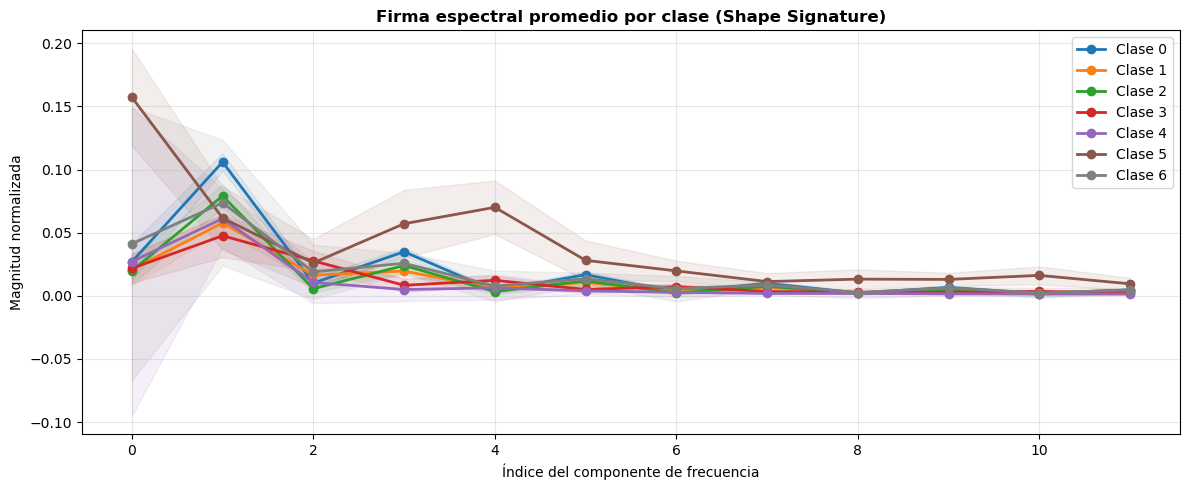

In [12]:
plt.figure(figsize=(12, 5))

colores_clase = plt.cm.tab10(np.linspace(0, 0.7, len(CLASES_ASIGNADAS)))

for i, clase in enumerate(CLASES_ASIGNADAS):
    mask = y_labels == clase
    promedio = X_descriptors[mask].mean(axis=0)
    std = X_descriptors[mask].std(axis=0)
    
    x_axis = np.arange(len(promedio))
    plt.plot(x_axis, promedio, marker="o", label=f"Clase {clase}", color=colores_clase[i], linewidth=2)
    plt.fill_between(x_axis, promedio - std, promedio + std, alpha=0.1, color=colores_clase[i])

plt.title("Firma espectral promedio por clase (Shape Signature)", fontweight="bold")
plt.xlabel("Índice del componente de frecuencia")
plt.ylabel("Magnitud normalizada")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div id="aumento_datos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Aumento de datos con Albumentations</h2>
</div>

Como sugiere la guía, se utiliza la librería **Albumentations** para generar variantes de las 
imágenes originales mediante rotaciones aleatorias. Esto incrementa la cantidad de datos de 
entrenamiento y mejora la robustez del clasificador frente a variaciones geométricas.

In [13]:
import albumentations as A

def augment_image(img, n_augmentations=3):
    """
    Genera n variantes de una imagen usando rotaciones aleatorias con Albumentations.
    """
    transform = A.Compose([
        A.Rotate(limit=(10, 350), border_mode=cv2.BORDER_CONSTANT, value=255, p=1.0),
    ])
    
    augmented = []
    for _ in range(n_augmentations):
        result = transform(image=img)
        augmented.append(result["image"])
    
    return augmented

<div style="color:#106ba3"><h3>Generar dataset aumentado</h3></div>

Por cada imagen original se generan 3 variantes rotadas. Los descriptores se recalculan para cada variante.

In [14]:
X_aug_desc = list(X_descriptors)  # empezamos con los originales
y_aug_labels = list(y_labels)
aug_count = 0

for img, contour, label in zip(images, X_contours, y_labels):
    augmented_imgs = augment_image(img, n_augmentations=3)
    
    for aug_img in augmented_imgs:
        _, aug_contour = preprocess_leaf(aug_img)
        
        if aug_contour is not None and len(aug_contour) >= 20:
            desc = extract_shape_signature(aug_contour)
            X_aug_desc.append(desc)
            y_aug_labels.append(label)
            aug_count += 1

X_aug_desc = np.array(X_aug_desc)
y_aug_labels = np.array(y_aug_labels)

print(f"Dataset original: {len(X_descriptors)} imágenes")
print(f"Imágenes aumentadas generadas: {aug_count}")
print(f"Dataset aumentado total: {len(X_aug_desc)} imágenes")
print(f"Distribución aumentada: {dict(Counter(y_aug_labels))}")

Dataset original: 450 imágenes
Imágenes aumentadas generadas: 1350
Dataset aumentado total: 1800 imágenes
Distribución aumentada: {np.int64(5): 224, np.int64(4): 292, np.int64(3): 288, np.int64(1): 252, np.int64(6): 248, np.int64(0): 236, np.int64(2): 260}


<div id="clasificacion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Clasificación y evaluación</h2>
</div>

<div style="color:#106ba3"><h3>División train / test (80% / 20%)</h3></div>

Se divide el dataset aumentado en 80% para entrenamiento y 20% para prueba, 
manteniendo la proporción de cada clase (stratify).

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_aug_desc, y_aug_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_aug_labels
)

print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba:        {len(X_test)} muestras")
print(f"\nDistribución train: {dict(Counter(y_train))}")
print(f"Distribución test:  {dict(Counter(y_test))}")

Entrenamiento: 1440 muestras
Prueba:        360 muestras

Distribución train: {np.int64(4): 234, np.int64(3): 230, np.int64(2): 208, np.int64(5): 179, np.int64(6): 198, np.int64(0): 189, np.int64(1): 202}
Distribución test:  {np.int64(4): 58, np.int64(3): 58, np.int64(6): 50, np.int64(1): 50, np.int64(0): 47, np.int64(5): 45, np.int64(2): 52}


<div style="color:#106ba3"><h3>Clasificador por distancia Euclídea (1-NN)</h3></div>

Como indica la guía, se clasifica cada imagen de test comparando su descriptor con los 
descriptores de entrenamiento usando la **distancia Euclídea**. La clase del vecino más cercano 
determina la predicción.

In [16]:
def classify_euclidean(X_train, y_train, X_test):
    """
    Clasificador 1-NN por distancia Euclídea.
    Para cada muestra de test, encuentra el vecino más cercano en train.
    """
    predictions = []
    
    for test_sample in X_test:
        # Calcular distancia Euclídea a todas las muestras de entrenamiento
        distances = np.sqrt(np.sum((X_train - test_sample) ** 2, axis=1))
        
        # Clase del vecino más cercano
        nearest_idx = np.argmin(distances)
        predictions.append(y_train[nearest_idx])
    
    return np.array(predictions)

y_pred = classify_euclidean(X_train, y_train, X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (Distancia Euclídea — 1-NN): {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy (Distancia Euclídea — 1-NN): 0.3361 (33.61%)


<div style="color:#106ba3"><h3>Reporte de clasificación</h3></div>

In [17]:
class_names = [f"Clase {c}" for c in CLASES_ASIGNADAS]
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     Clase 0       0.33      0.28      0.30        47
     Clase 1       0.26      0.30      0.28        50
     Clase 2       0.33      0.35      0.34        52
     Clase 3       0.35      0.36      0.36        58
     Clase 4       0.34      0.34      0.34        58
     Clase 5       0.39      0.49      0.44        45
     Clase 6       0.35      0.24      0.29        50

    accuracy                           0.34       360
   macro avg       0.34      0.34      0.33       360
weighted avg       0.34      0.34      0.33       360



<div style="color:#106ba3"><h3>Matriz de confusión</h3></div>

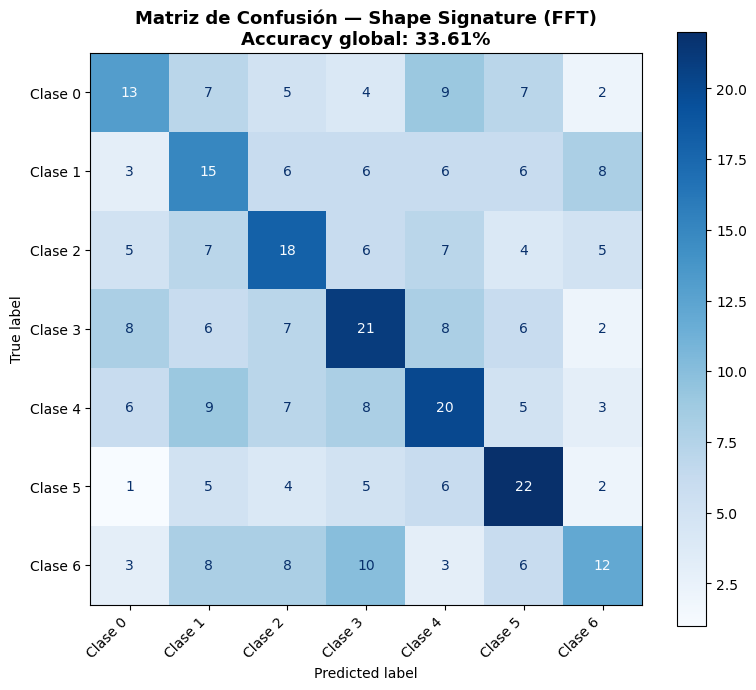

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap="Blues", ax=ax, colorbar=True)
plt.title("Matriz de Confusión — Shape Signature (FFT)\n"
          f"Accuracy global: {accuracy:.2%}", fontweight="bold", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div style="color:#106ba3"><h3>Ejemplos de formas que confunde</h3></div>

Se muestran ejemplos gráficos donde el clasificador asignó una clase incorrecta, 
indicando la etiqueta real y la predicha.

Total de errores: 239 de 360 (66.4%)
Mostrando 8 ejemplos de confusión:



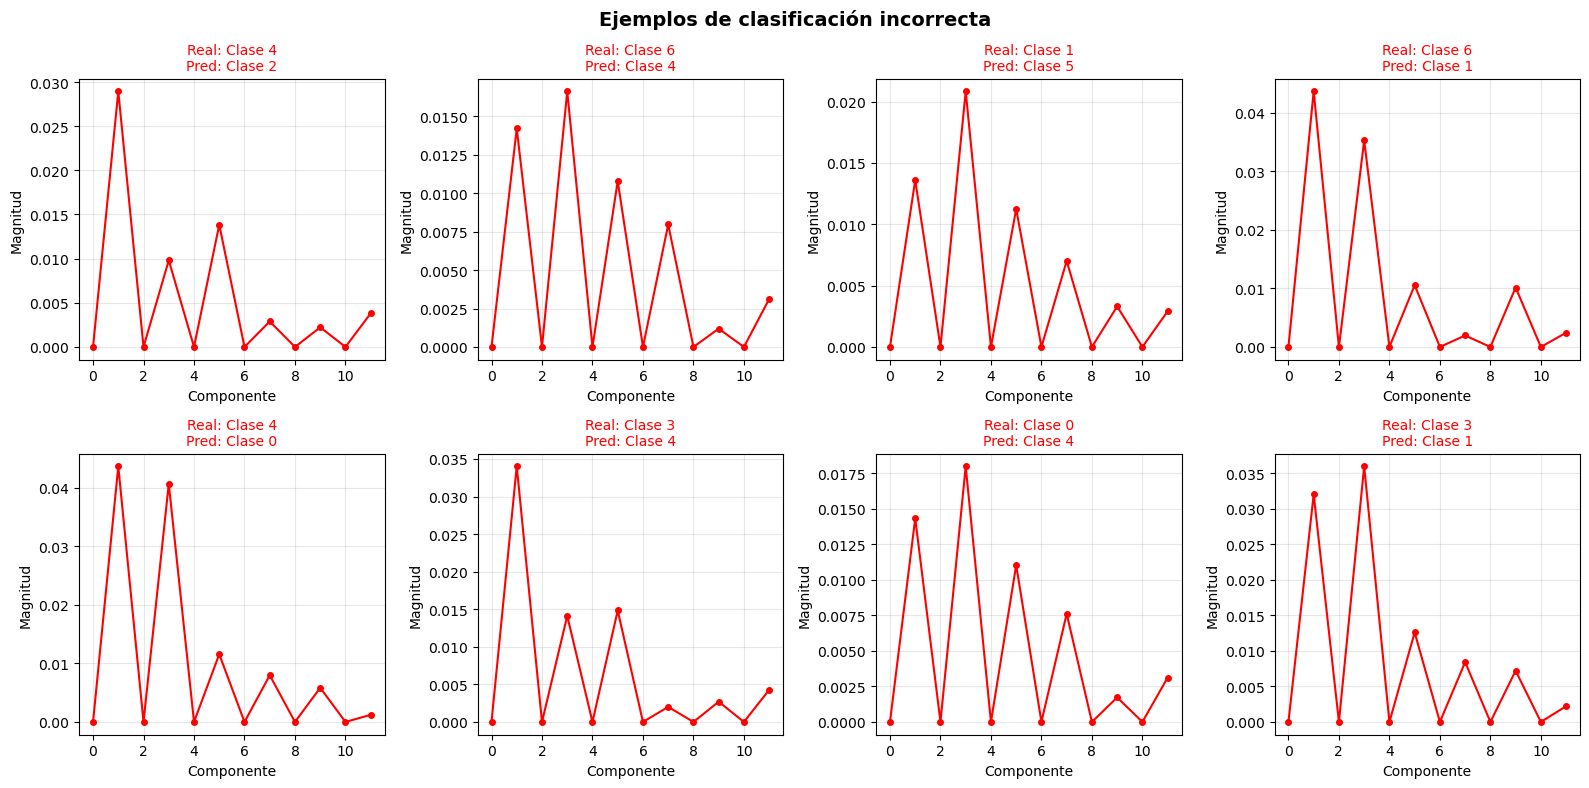

In [19]:
# Necesitamos mapear los índices de test a imágenes originales
# Para las muestras del dataset original (no aumentadas), mostramos la imagen
errores = np.where(y_test != y_pred)[0]

if len(errores) == 0:
    print("¡No hay errores de clasificación!")
else:
    n_show = min(8, len(errores))
    print(f"Total de errores: {len(errores)} de {len(y_test)} ({len(errores)/len(y_test)*100:.1f}%)")
    print(f"Mostrando {n_show} ejemplos de confusión:\n")
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Ejemplos de clasificación incorrecta", fontsize=14, fontweight="bold")
    
    for i in range(n_show):
        err_idx = errores[i]
        ax = axes[i // 4][i % 4]
        
        # Graficar el descriptor erróneo
        ax.plot(X_test[err_idx], "r-o", markersize=4, linewidth=1.5)
        ax.set_title(f"Real: Clase {y_test[err_idx]}\nPred: Clase {y_pred[err_idx]}",
                     fontsize=10, color="red" if y_test[err_idx] != y_pred[err_idx] else "green")
        ax.set_xlabel("Componente")
        ax.set_ylabel("Magnitud")
        ax.grid(True, alpha=0.3)
    
    # Ocultar axes vacíos
    for i in range(n_show, 8):
        axes[i // 4][i % 4].axis("off")
    
    plt.tight_layout()
    plt.show()

<div style="color:#106ba3"><h3>Análisis de confusiones entre clases</h3></div>

Se identifican los pares de clases con mayor tasa de confusión.

In [20]:
# Encontrar los pares más confundidos
cm_norm = cm.astype(float)
np.fill_diagonal(cm_norm, 0)  # ignorar la diagonal

confusiones = []
for i in range(len(CLASES_ASIGNADAS)):
    for j in range(len(CLASES_ASIGNADAS)):
        if cm_norm[i][j] > 0:
            confusiones.append((CLASES_ASIGNADAS[i], CLASES_ASIGNADAS[j], int(cm_norm[i][j])))

confusiones.sort(key=lambda x: x[2], reverse=True)

print("Principales confusiones (Real → Predicha: cantidad):")
print("=" * 45)
for real, pred, count in confusiones[:10]:
    print(f"  Clase {real} → Clase {pred}: {count} errores")

Principales confusiones (Real → Predicha: cantidad):
  Clase 6 → Clase 3: 10 errores
  Clase 0 → Clase 4: 9 errores
  Clase 4 → Clase 1: 9 errores
  Clase 1 → Clase 6: 8 errores
  Clase 3 → Clase 0: 8 errores
  Clase 3 → Clase 4: 8 errores
  Clase 4 → Clase 3: 8 errores
  Clase 6 → Clase 1: 8 errores
  Clase 6 → Clase 2: 8 errores
  Clase 0 → Clase 1: 7 errores


<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Exportar descriptores para la aplicación móvil</h2>
</div>

Se guardan los descriptores de entrenamiento en un formato que pueda ser leído desde C++ 
en la aplicación Android. Cada línea contiene la etiqueta de clase seguida de los 12 valores del descriptor.

In [21]:
# Exportar como archivo de texto plano (fácil de leer en C++)
output_path = "descriptors_train.txt"

with open(output_path, "w") as f:
    f.write(f"{len(X_train)} {X_train.shape[1]}\n")  # header: num_samples num_features
    for desc, label in zip(X_train, y_train):
        values = " ".join([f"{v:.8f}" for v in desc])
        f.write(f"{label} {values}\n")

print(f"Descriptores exportados a: {output_path}")
print(f"  → {len(X_train)} muestras de entrenamiento con {X_train.shape[1]} componentes cada una")
print(f"  → Listo para integrarse en la app Android (C++/JNI)")

Descriptores exportados a: descriptors_train.txt
  → 1440 muestras de entrenamiento con 12 componentes cada una
  → Listo para integrarse en la app Android (C++/JNI)


<div id="conclusiones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Conclusiones</h2>
</div>

1. **La normalización por el primer armónico es esencial para la invarianza a escala**

    La división de los coeficientes de Fourier por $|F(1)|$ permite que el descriptor no dependa del tamaño de la hoja en la imagen, lo cual es crítico para la aplicación móvil donde la distancia cámara-hoja varía.

2. **El uso de magnitudes descarta la fase y otorga invarianza a la rotación**

    Al tomar únicamente $|F(k)|$ y descartar la fase, el descriptor se vuelve independiente del punto de inicio del contorno y de la orientación de la hoja.

3. **El aumento de datos mediante rotaciones con Albumentations mejora la robustez**

    La generación de variantes rotadas incrementa la diversidad del conjunto de entrenamiento, lo que se traduce en una mayor capacidad de generalización del clasificador.

4. **La distancia Euclídea sobre descriptores de Fourier proporciona una clasificación eficiente**

    El clasificador 1-NN por distancia Euclídea resulta adecuado para este tipo de descriptores compactos (12 dimensiones), ofreciendo un balance entre simplicidad computacional y precisión.

5. **El preprocesamiento condiciona directamente la calidad del descriptor**

    La correcta binarización y extracción del contorno principal es el paso más crítico del pipeline. Un contorno mal segmentado produce una firma espectral distorsionada que degrada significativamente la clasificación.

<div id="referencias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px">
<h2>Referencias</h2>
</div>

[1] Wu, S. G., et al. (2007). *A Leaf Recognition Algorithm for Plant Classification Using Probabilistic Neural Network*. IEEE International Symposium on Signal Processing and Information Technology.

[2] Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson Education.

[3] OpenCV Documentation. *Discrete Fourier Transform, Moments, and Contours*. https://docs.opencv.org/

[4] Albumentations Documentation. *Image Augmentation Library*. https://albumentations.ai/

[5] Flavia Leaf Dataset. http://flavia.sourceforge.net/